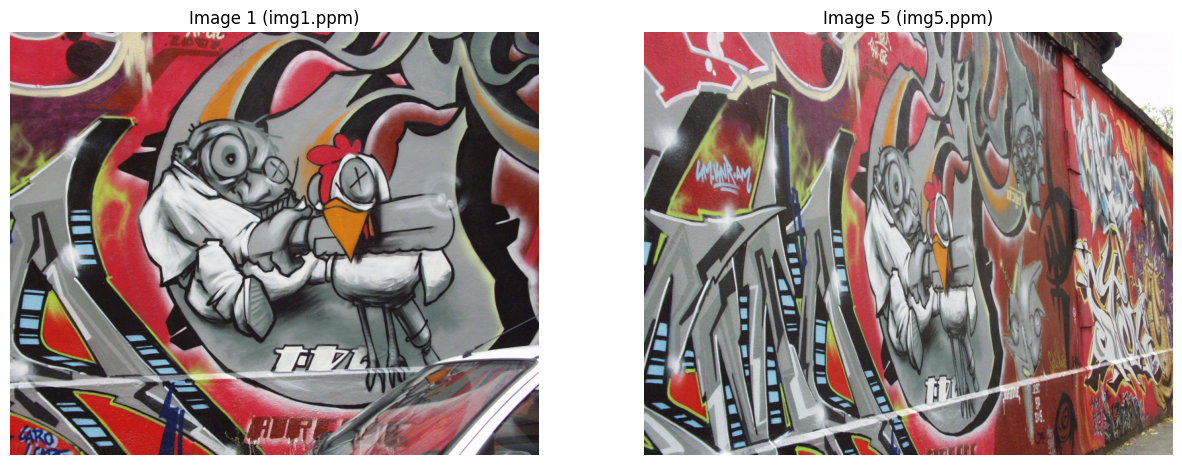

In [1]:
import cv2
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread('graf/img1.ppm')
img2 = cv2.imread('graf/img5.ppm')

# Convert BGR → RGB for correct colors in matplotlib
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Display images side by side
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img1_rgb)
plt.title("Image 1 (img1.ppm)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2_rgb)
plt.title("Image 5 (img5.ppm)")
plt.axis('off')

plt.show()


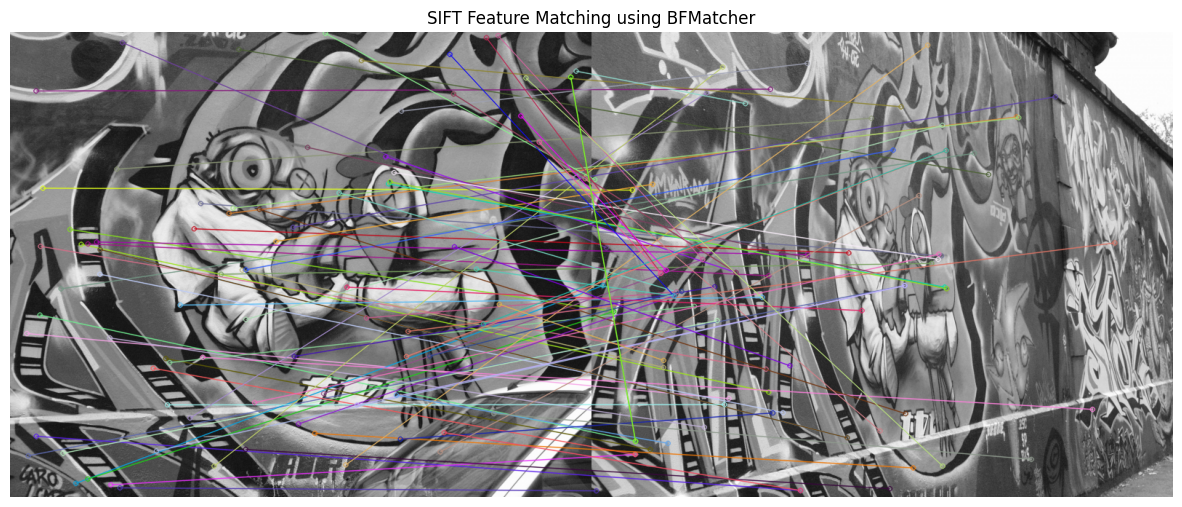

Number of keypoints in Image 1: 2674
Number of keypoints in Image 2: 3923
Number of good matches: 87


In [64]:
import cv2
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread('graf/img1.ppm')  # Portable Pixmap format
img2 = cv2.imread('graf/img5.ppm')

# Convert to grayscale (SIFT works only on intensity)
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Initialize SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Use Brute-Force Matcher
# For SIFT, use L2-norm (Euclidean distance)
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

# Match descriptors using KNN (k = 2)
matches = bf.knnMatch(des1, des2, k=2)

# Apply Lowe’s ratio test to keep only good matches
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# Draw matches
matched_img = cv2.drawMatches(gray1, kp1, gray2, kp2, good_matches, None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display result
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
cv2.imwrite('matched_image_bf.png', matched_img)
plt.title("SIFT Feature Matching using BFMatcher")
plt.axis('off')
plt.show()

# Print keypoint and match information
print(f"Number of keypoints in Image 1: {len(kp1)}")
print(f"Number of keypoints in Image 2: {len(kp2)}")
print(f"Number of good matches: {len(good_matches)}")


Good matches: 87
RANSAC inliers: 8/87
Estimated Homography:
 [[ 2.53131067e+00  1.98419636e+00  2.95221514e+00]
 [ 1.95794065e+00 -9.21507597e-01  1.47976557e+03]
 [ 5.81660451e-03  2.90822460e-03  1.00000000e+00]]


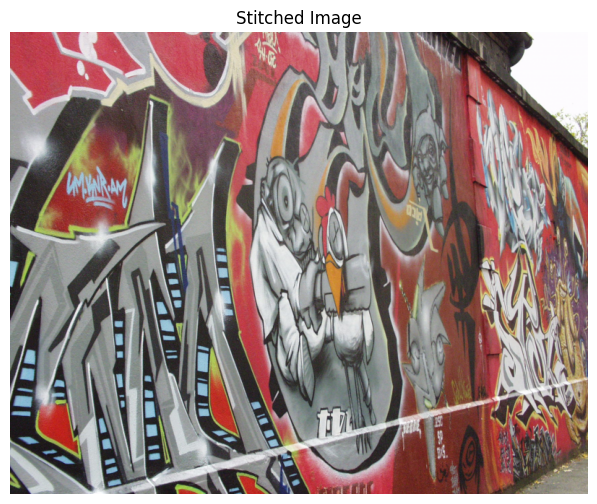

In [76]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

img1 = cv2.imread('graf/img1.ppm')  # Image to be stitched
img5 = cv2.imread('graf/img5.ppm')  # Base image


# Step 2: SIFT features
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1, None)
kp5, des5 = sift.detectAndCompute(img5, None)

# Step 3: Match descriptors with Lowe's ratio test
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des5, k=2)
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)
print(f"Good matches: {len(good_matches)}")


# Step 4: RANSAC helper functions
def compute_homography(src_pts, dst_pts):
    """Compute homography from 4 points using DLT"""
    A = []
    for i in range(4):
        x, y = src_pts[i][0], src_pts[i][1]
        u, v = dst_pts[i][0], dst_pts[i][1]
        A.append([-x, -y, -1, 0, 0, 0, u*x, u*y, u])
        A.append([0, 0, 0, -x, -y, -1, v*x, v*y, v])
    A = np.array(A)
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)
    return H / H[2, 2]
def get_inliers(H, src_pts, dst_pts, threshold=3.0):
    """Compute inliers for homography"""
    pts = np.hstack([src_pts, np.ones((len(src_pts),1))])
    projected = (H @ pts.T).T
    projected /= projected[:,2][:, np.newaxis]
    dists = np.linalg.norm(projected[:, :2] - dst_pts, axis=1)
    inliers = np.where(dists < threshold)[0]
    return inliers
def ransac_homography(src_pts, dst_pts, iterations=5000, threshold=6.0):
    best_H = None
    best_inliers = []
    n_points = 4
    for i in range(iterations):
        idx = np.random.choice(len(src_pts), n_points, replace=False)
        H = compute_homography(src_pts[idx], dst_pts[idx])
        inliers = get_inliers(H, src_pts, dst_pts, threshold)
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_H = H
    print(f"RANSAC inliers: {len(best_inliers)}/{len(src_pts)}")
    # Recompute H with all inliers
    if best_H is not None and len(best_inliers) > 4:
        best_H = compute_homography(src_pts[best_inliers[:4]], dst_pts[best_inliers[:4]])
    return best_H

# Step 5: Extract matched points
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches])
dst_pts = np.float32([kp5[m.trainIdx].pt for m in good_matches])


# Step 6: Compute homography with RANSAC
H = ransac_homography(src_pts, dst_pts)
print("Estimated Homography:\n", H)

# Step 7: Warp img1 onto img5
h5, w5 = img5.shape[:2]
h1, w1 = img1.shape[:2]

# Warp img1 using the homography
warped_img1 = cv2.warpPerspective(img1, H, (w5, h5))

# Simple blending using mask
mask = (warped_img1 > 0).astype(np.uint8)
stitched = img5.copy()
stitched[mask[:,:,0]==1] = warped_img1[mask[:,:,0]==1]


# Step 8: Display results
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(stitched, cv2.COLOR_BGR2RGB))
cv2.imwrite('stitched_image_new.png', stitched)
plt.title("Stitched Image")
plt.axis('off')
plt.show()


In [ ]:
import numpy as np

# --- Step 1: Load the given homography ---
# Assume the text file has 3 rows of 3 numbers each
H_given = np.loadtxt("graf/H1to5p")  
print("Given Homography:\n", H_given) 

# --- Step 2: Normalize both (optional but recommended) ---
H_comp = H / H[2,2]
H_given /= H_given[2,2]

# --- Step 3: Element-wise difference ---
diff = np.abs(H_comp - H_given)
print("Element-wise absolute difference:\n", diff)

# --- Step 4: Frobenius norm (overall difference) ---
fro_norm = np.linalg.norm(H_comp - H_given, 'fro')
print("Frobenius norm of difference:", fro_norm)

# --- Step 5: Geometric error on points (optional) ---
# Assume you still have src_pts (Nx2 array of points in img1)
def transform_points(H, pts):
    pts_h = np.hstack([pts, np.ones((pts.shape[0], 1))])
    pts_trans = H @ pts_h.T
    pts_trans = pts_trans[:2, :] / pts_trans[2, :]
    return pts_trans.T

pts_trans_comp = transform_points(H_comp, src_pts)
pts_trans_given = transform_points(H_given, src_pts)

mse = np.mean(np.linalg.norm(pts_trans_comp - pts_trans_given, axis=1)**2)
print("Mean squared error between transformed points:", mse)


Given Homography:
 [[ 6.2544644e-01  5.7759174e-02  2.2201217e+02]
 [ 2.2240536e-01  1.1652147e+00 -2.5605611e+01]
 [ 4.9212545e-04 -3.6542424e-05  1.0000000e+00]]
Element-wise absolute difference:
 [[1.90586423e+00 1.92643718e+00 2.19059955e+02]
 [1.73553529e+00 2.08672230e+00 1.50537119e+03]
 [5.32447906e-03 2.94476703e-03 0.00000000e+00]]
Frobenius norm of difference: 1521.231205255292
Mean squared error between transformed points: 99407.19012785493
